In [5]:
# !pip install matplotlib

Применим основные категории аугментаций к тестовому изображению и визуализируем результат функцией plot_image. 

Скачайте тестовое изображение — именно его мы будем проводить к квадрату со стороной SIZE. 

In [1]:
import urllib.request

def download_image_urllib(url, file_path):
    try:
        urllib.request.urlretrieve(url, file_path)
        print(f"Изображение успешно скачано и сохранено как {file_path}")
    except Exception as e:
        print(f"Ошибка при загрузке изображения: {e}")

# Пример использования
image_url = 'https://code.s3.yandex.net/deep-learning/corgi.jpg'
save_path = 'data/corgi.jpg'
download_image_urllib(image_url, save_path)

Изображение успешно скачано и сохранено как data/corgi.jpg


In [12]:
import albumentations as A
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np

SIZE = 224


# функция визуализирует исходное и аугментированное изображение
def plot_image(original, transformed, figsize=(5, 2.5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # оригинал
    ax1.imshow(original, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')

    # аугментации
    ax2.imshow(transformed, cmap='gray')
    ax2.set_title('transformed')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()


# загружаем и сохраняем картинку
url = "https://raw.githubusercontent.com/jigsawpieces/dog-api-images/main/corgi/14917192_10154550690893449_81787730512372227_o.jpg"
response = requests.get(url, stream=True)

with open("data/corgi.jpg", "wb") as f:
    f.write(response.content)

img = np.array(Image.open("data/corgi.jpg"))


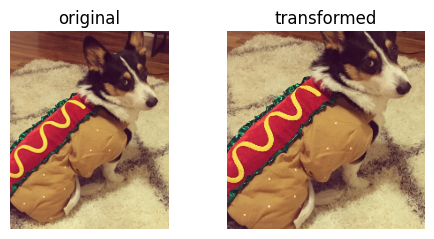

In [13]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0)
    ],
    seed=42,
)

plot_image(img, transforms(image=img)["image"])

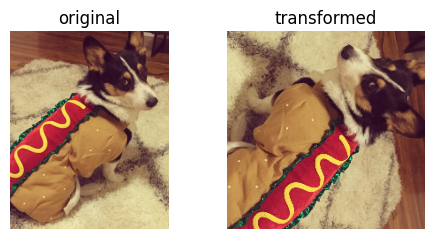

In [14]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1) # не принимает других аргументов на вход
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

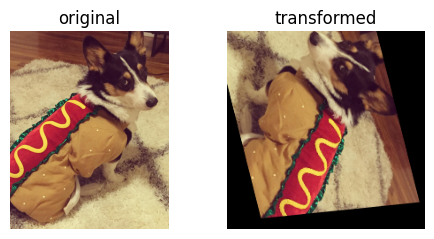

In [15]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(
                scale=(0.8, 1.2), rotate=(-15, 15), fill=0,
                translate_percent=(-0.1, 0.1), shear=(-10, 10), p=1
            ),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

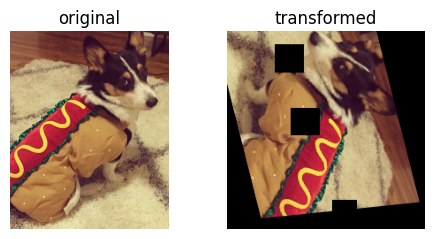

In [18]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
    ],
    seed=4,
)


plot_image(img, transforms(image=img)["image"])

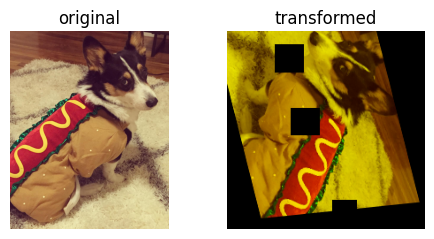

In [19]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

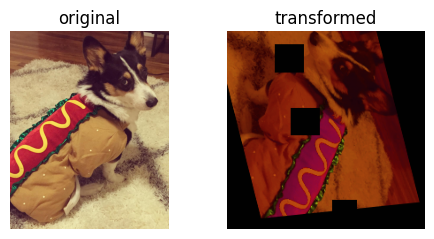

In [20]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

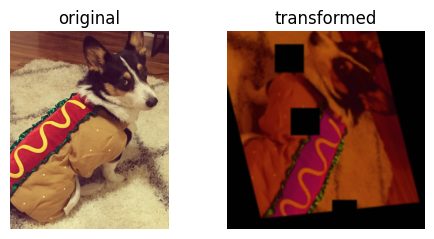

In [ ]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

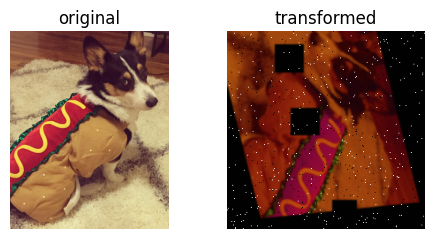

In [22]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
        A.SaltAndPepper(amount=(0.01, 0.06), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

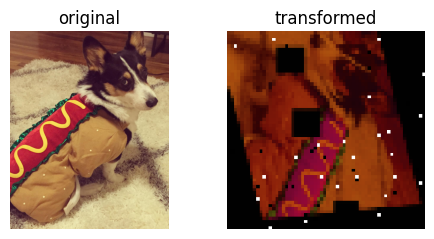

In [23]:
transforms = A.Compose(
    [
        A.SmallestMaxSize(max_size=SIZE, p=1.0),
        A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
        A.SquareSymmetry(p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.CoarseDropout(num_holes_range=(2, 8),
                        hole_height_range=(int(0.07 * SIZE), int(0.15 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.15 * SIZE)),
                        fill=0,
                        p=1.0),
        A.ChannelDropout(channel_drop_range=(1, 1), fill=0, p=0.3),
        A.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 10), p=0.5),
        A.SaltAndPepper(amount=(0.01, 0.06), p=0.5),
        A.Downscale(scale_range=(0.25, 0.5), p=0.5),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"])

Используйте комбинацию аугментаций с произвольными параметрами Affine, Resize, MotionBlur на изображении img и визуализируйте его (визуализация уже есть в прекоде). Выберите правильный порядок для аугментации. Установите вероятность равной 1, seed=42. Целевой масштаб указан в параметре SIZE.

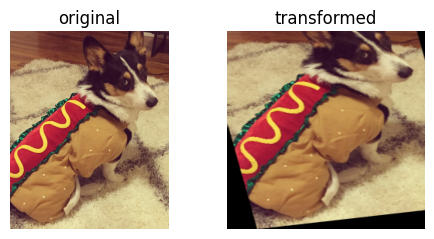

In [30]:
import albumentations as A
from PIL import Image
import requests
import matplotlib.pyplot as plt


SIZE = 256


def plot_image(original, transformed, figsize=(5, 2.5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # оригинал
    ax1.imshow(original, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')

    # аугментации
    ax2.imshow(transformed, cmap='gray')
    ax2.set_title('transformed')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()


transforms = A.Compose(
    [
        A.Resize(height=SIZE,
                 width=SIZE,
                 p=1),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.MotionBlur(blur_limit=(3, 10), p=1),
    ],
    seed=42,
)

img = np.array(Image.open("data/corgi.jpg"))
plot_image(img, transforms(image=img)["image"])

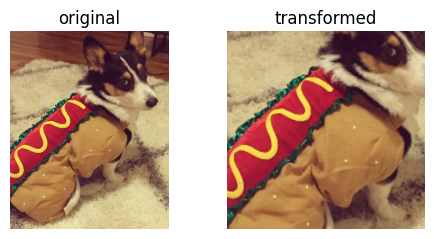

In [31]:
transforms = A.Compose([
    A.SmallestMaxSize(max_size=SIZE, p=1.0),
    A.RandomCrop(height=SIZE, width=SIZE, p=1.0),
    A.OneOf([
        A.Affine(rotate=(-15, 15), shear=(-10, 10), p=0.8),
        A.Perspective(scale=(0.05, 0.1), p=0.8)
    ], p=0.7)
], seed=42)

plot_image(img, transforms(image=img)["image"])

1. Используйте комбинацию аугментаций с произвольными параметрами: RandomResizedCrop, случайным выбором одной из аугментаций СoarseDropout или GridDropout на изображении img.
2. Визуализируйте его (код уже написан).
3. Установите вероятность всех аугментаций равной 1, seed=42.

Целевой масштаб указан в параметре SIZE. Примените нормализацию на каждом изображении в отдельности.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.214861630762824..2.3163882582339768].


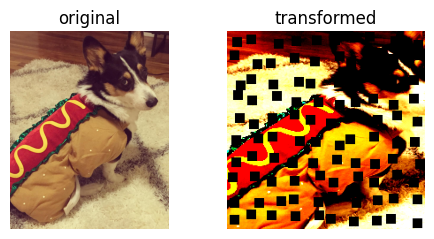

In [40]:
import albumentations as A
from PIL import Image
import requests
import matplotlib.pyplot as plt


SIZE = 224

transforms = A.Compose([
    A.RandomResizedCrop((SIZE, SIZE), p=1),
    A.OneOf([
        A.CoarseDropout(p=1),
        A.GridDropout(p=1),
    ], p=1)
], seed=42)

transforms = A.Compose([
    transforms,
    A.Normalize(normalization="image", p=1),
], seed=42)

plot_image(img, transforms(image=img)["image"])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2508401060050047..2.1833938666727346].


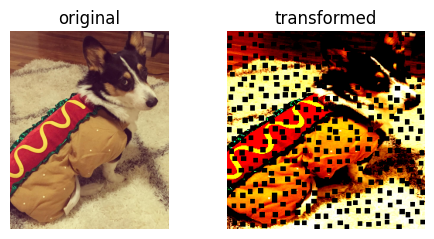

In [43]:
import albumentations as A
from PIL import Image
import requests
import matplotlib.pyplot as plt

SIZE = 256

transforms = A.Compose([
    A.RandomResizedCrop(
        size=(SIZE, SIZE), scale=(0.8, 1.0), ratio=(0.75, 1.33), p=1.0),
    A.OneOf([
        A.CoarseDropout(num_holes_range=(1, 8),
                        hole_height_range=(int(0.1 * SIZE), int(0.2 * SIZE)),
                        hole_width_range=(int(0.1 * SIZE), int(0.2 * SIZE)),
                        p=1.0),
        A.GridDropout(ratio=0.5,
                      unit_size_range=(int(0.05 * SIZE), int(0.1 * SIZE)),
                      p=1),
    ], p=1),
    A.Normalize(normalization="image",
                p=1.0),
], seed=42)

plot_image(img, transforms(image=img)["image"])